We're going to run a grid of stars from 5 to 9 solar masses for a range of metallicities to assess what masses lead to core-collapse in COSMIC.

In [93]:
from cosmic.sample.initialbinarytable import InitialBinaryTable
from cosmic.evolve import Evolve
import numpy as np
import matplotlib.pyplot as plt
import cogsworth
from multiprocessing import Pool

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [5]:
from cogsworth.utils import default_BSE_settings

In [101]:
mass_step = 0.025
mass_range = np.arange(5.8, 8.1 + mass_step, mass_step)

metallicity_grid = np.geomspace(1e-4, 0.03, 200)

M, Z = np.meshgrid(mass_range, metallicity_grid, indexing='ij')
m_flat = M.ravel()
z_flat = Z.ravel()
initial_binaries = InitialBinaryTable.InitialBinaries(
    m1=M.ravel(),
    m2=np.zeros(len(m_flat)),
    porb=-1 * np.ones(len(m_flat)),
    ecc=-1 * np.ones(len(m_flat)),
    tphysf=13700 * np.ones(len(m_flat)),
    kstar1=np.ones(len(m_flat)),
    kstar2=np.zeros(len(m_flat)),
    metallicity=z_flat,
)
len(initial_binaries)

18600

In [102]:
with Pool(32) as pool:
    bpp, bcm, initC, kick_info = Evolve.evolve(initial_binaries, pool=pool, BSEDict=default_BSE_settings)
final_bpp = bpp.drop_duplicates(subset="bin_num", keep="last")

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cosmic/evolve.py:286: UserWarning: The value for binfrac in initial binary table is being overwritten by the value of binfrac from either the params file or the BSEDict.
  warnings.warn("The value for {0} in initial binary table is being "


In [115]:
# find the minimum initial mass in initC where final_bpp has kstar_1 == 13
exploding_stars = final_bpp[final_bpp["kstar_1"] == 13]
exploding_initC = initC[initC["bin_num"].isin(exploding_stars["bin_num"])]
min_exploding_mass = exploding_initC.groupby("metallicity")["mass_1"].min().reset_index()

<Axes: title={'center': 'Minimum Initial Mass for Core-Collapse vs Metallicity'}, xlabel='Metallicity', ylabel='Minimum Initial Mass for Core-Collapse (M$_\\odot$)'>

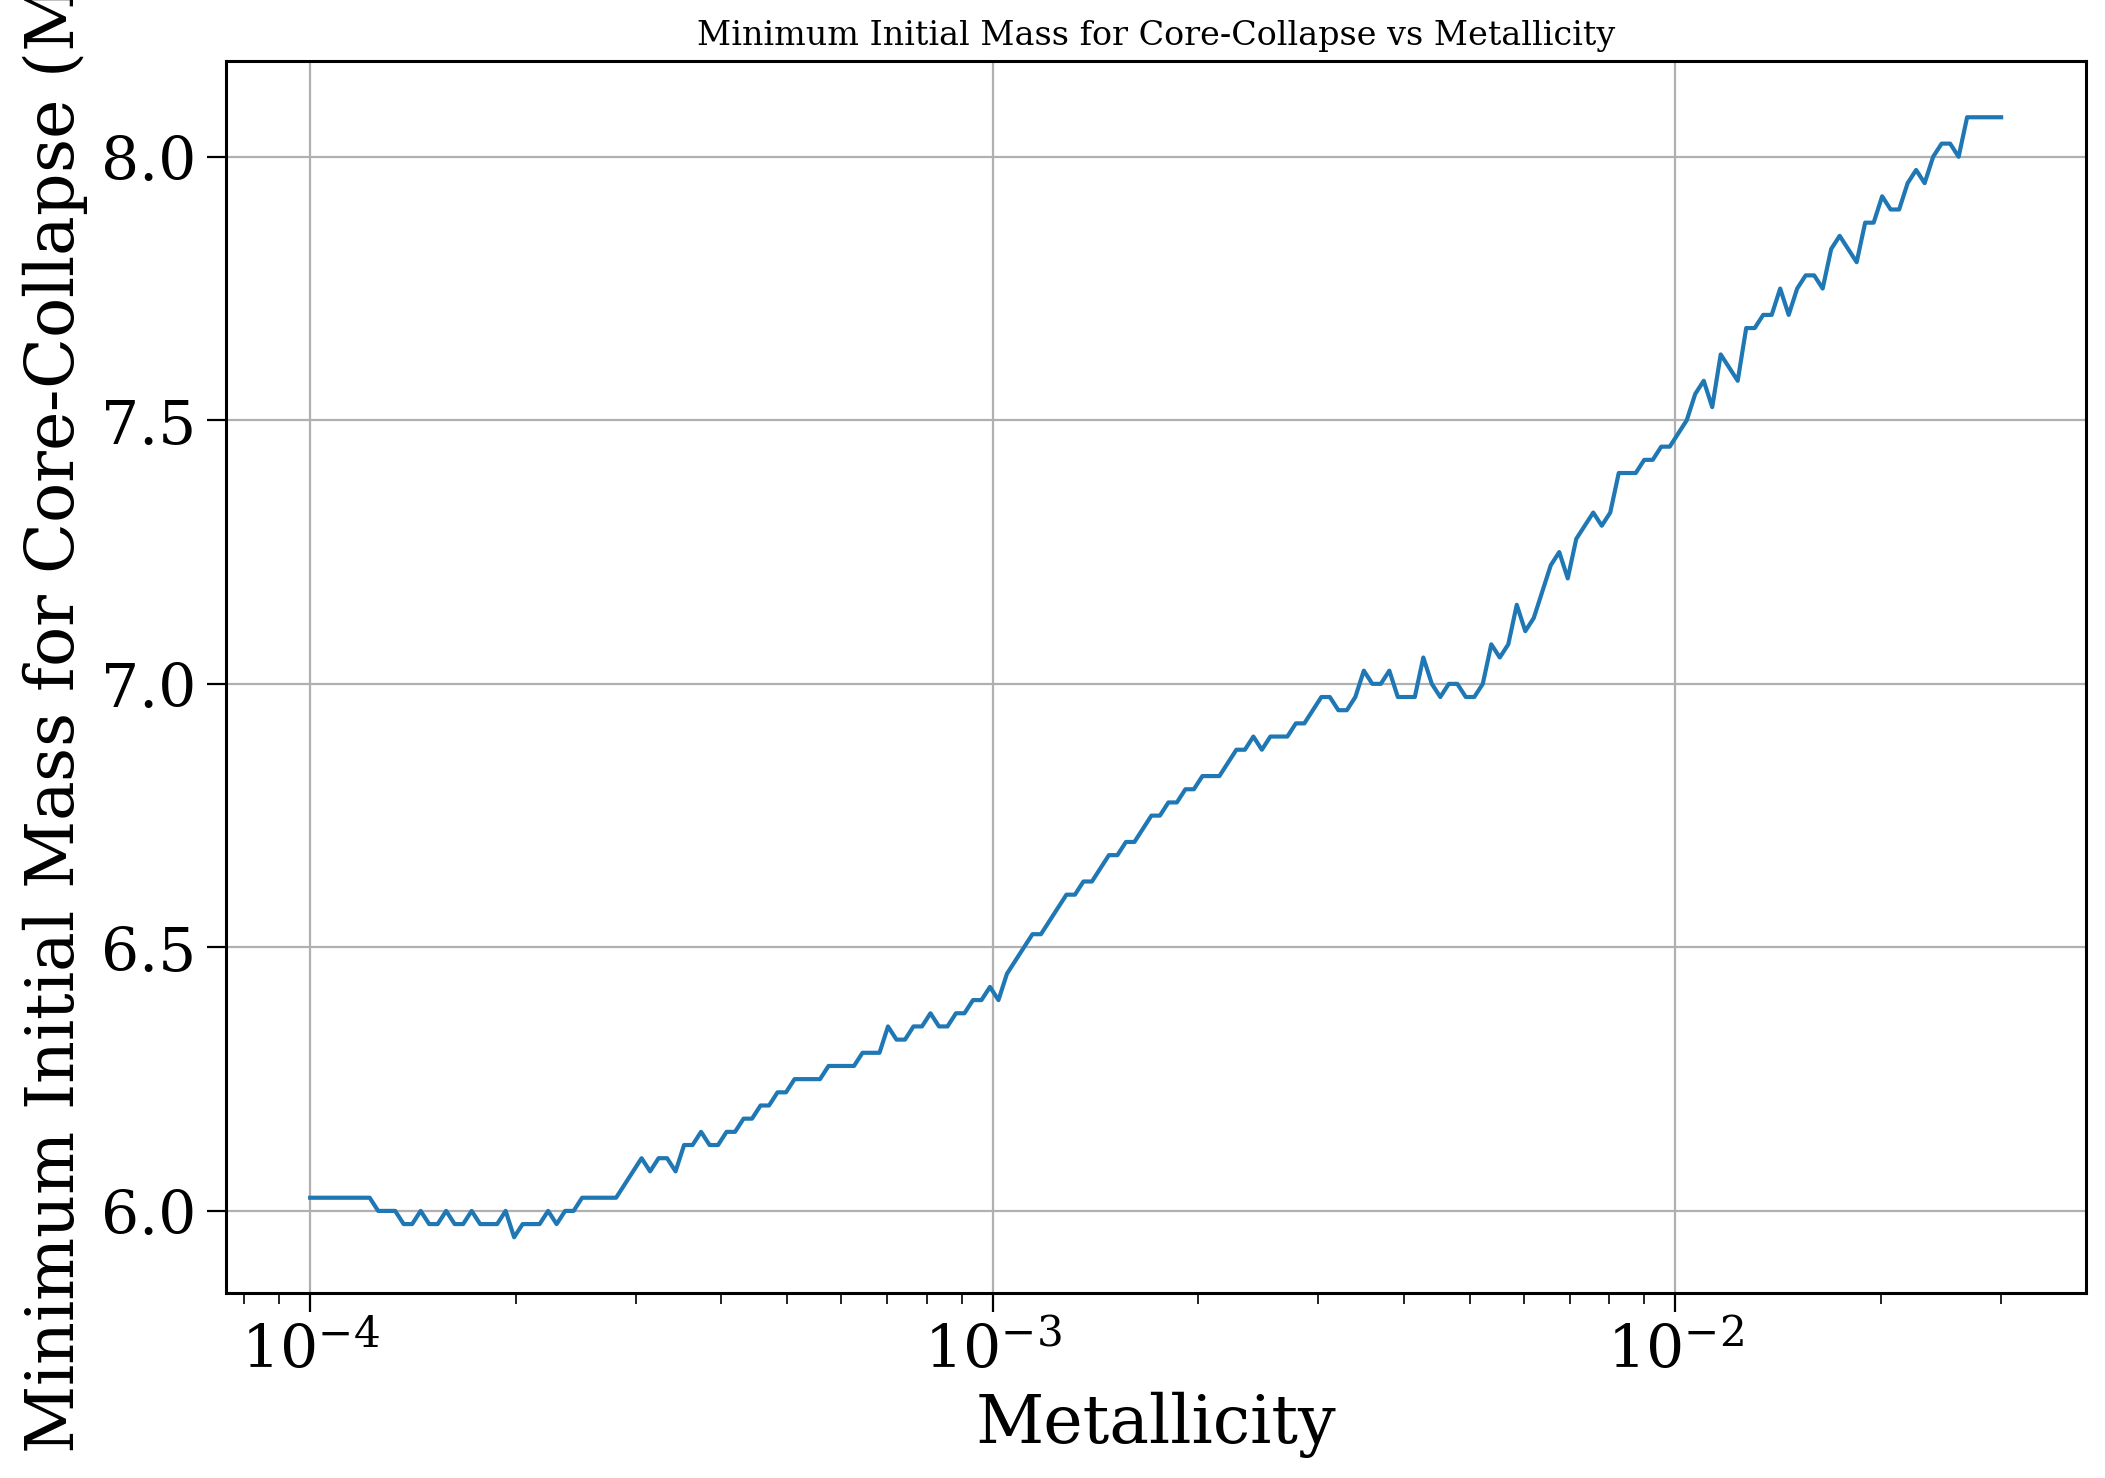

In [117]:
min_exploding_mass.plot(
    x="metallicity",
    y="mass_1",
    logx=True,
    xlabel="Metallicity",
    ylabel="Minimum Initial Mass for Core-Collapse (M$_\odot$)",
    title="Minimum Initial Mass for Core-Collapse vs Metallicity",
    legend=False,
    grid=True,
)

In [122]:
min_exploding_mass

,metallicity,mass_1
0,0.000100,6.025
1,0.000103,6.025
2,0.000106,6.025
3,0.000109,6.025
4,0.000112,6.025
...,...,...
195,0.026750,8.075
196,0.027528,8.075
197,0.028329,8.075
198,0.029152,8.075


In [124]:
min_exploding_mass.to_hdf("~/ceph/underworld/cosmic_explode_crit.h5", key="min_exploding_mass", mode="w")

/tmp/ipykernel_1245112/3742209341.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


[Text(0.5, 0, 'Metallicity'),
 Text(0, 0.5, 'Initial Mass (M$_\\odot$)'),
 None,
 (0.0001, 0.03),
 (5.6, 8.35)]

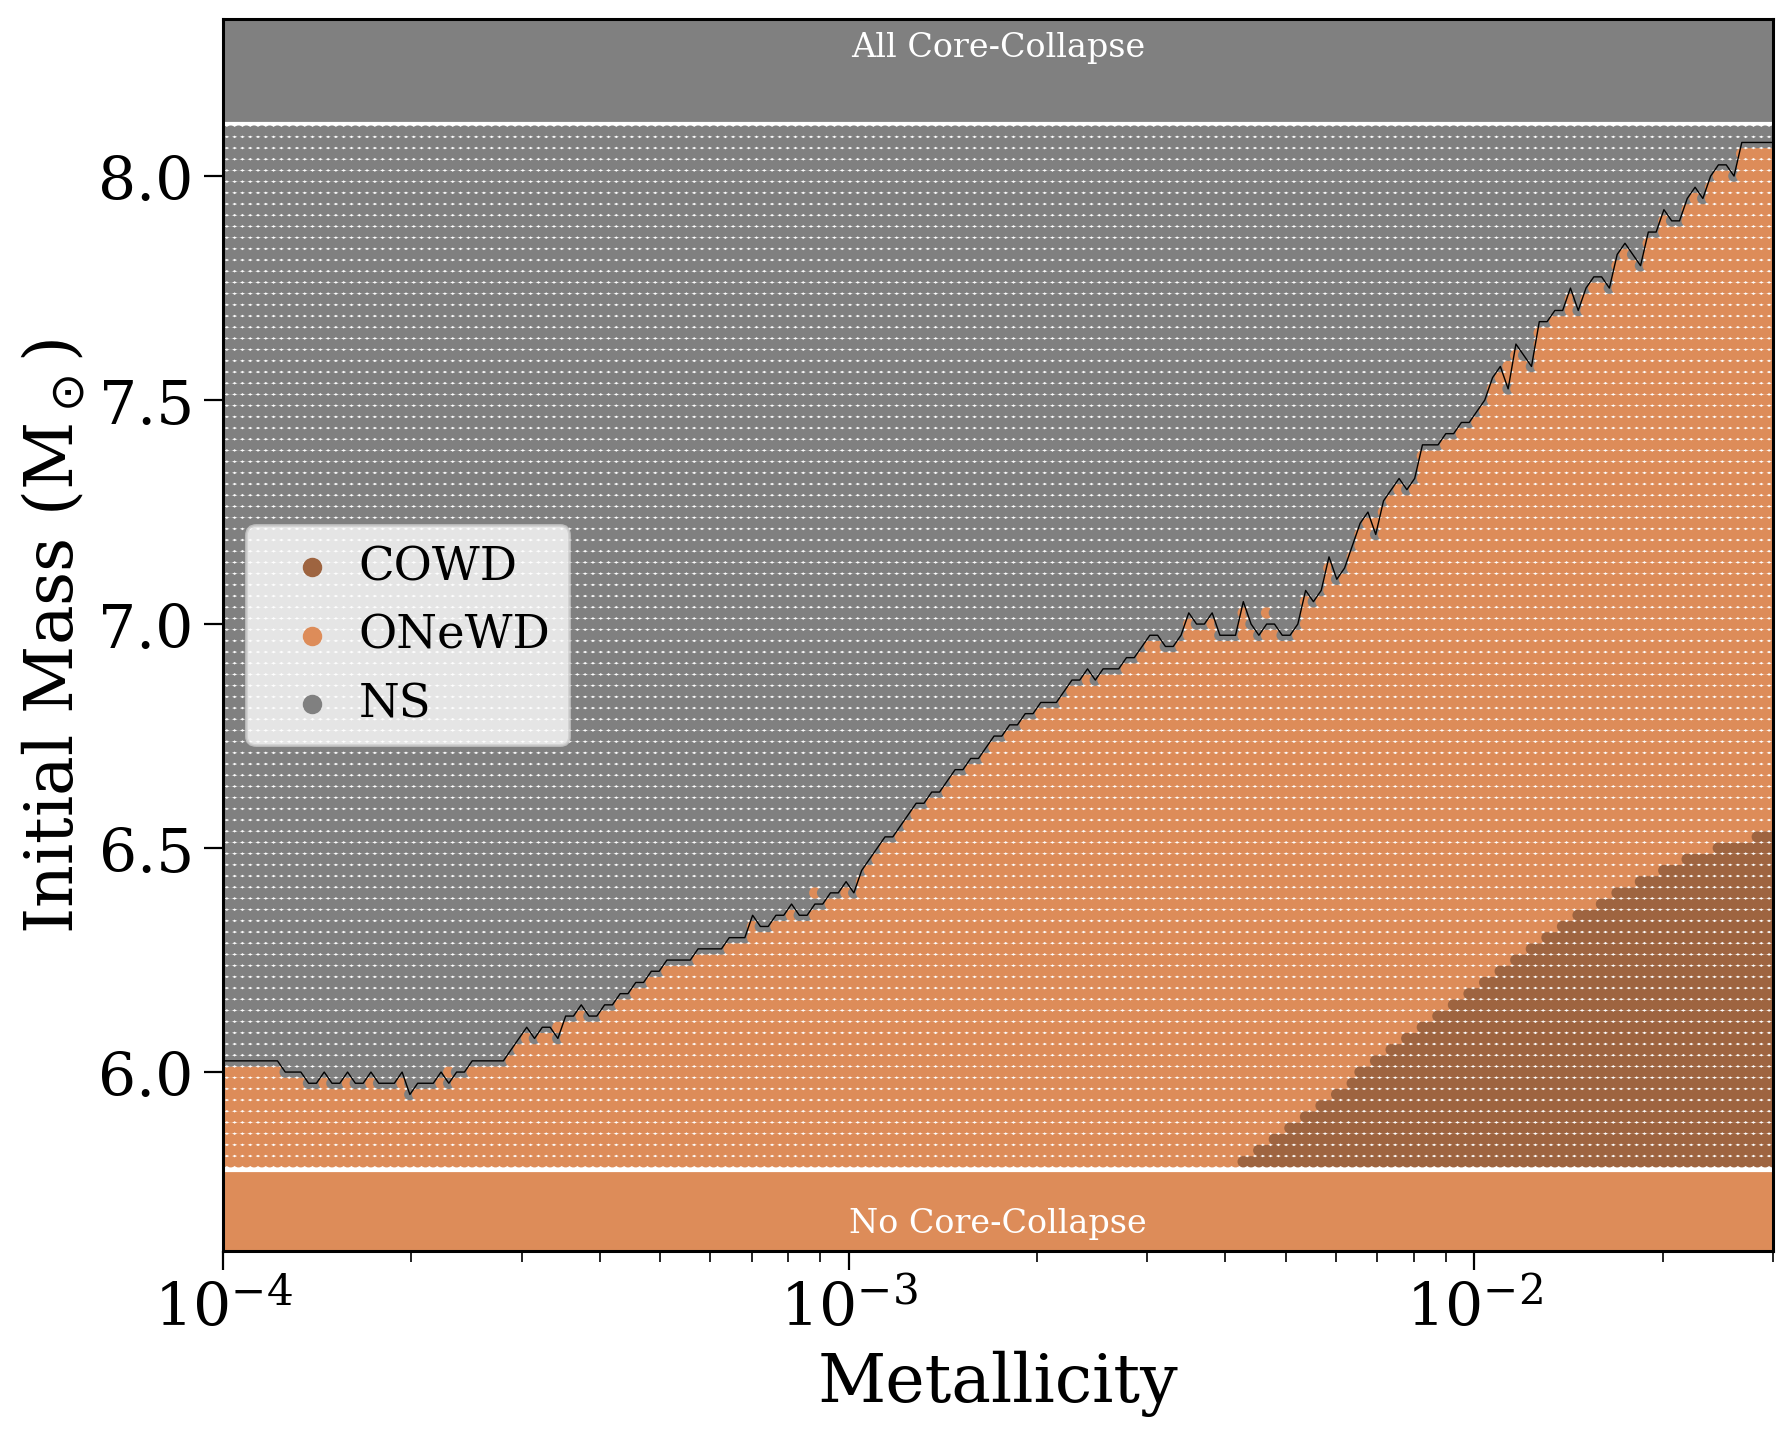

In [121]:
fig, ax = plt.subplots(figsize=(10, 8))

colours = [cogsworth.utils.kstar_translator[k]["colour"] for k in final_bpp['kstar_1']]

ax.scatter(initC["metallicity"], initC["mass_1"],
           c=colours,
           s=10)

ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
        c='black', lw=0.5)

ax.axhspan(max(mass_range) + mass_step, 100, color=cogsworth.utils.kstar_translator[13]["colour"])
ax.axhspan(0, min(mass_range) - mass_step, color=cogsworth.utils.kstar_translator[12]["colour"])

ax.annotate('No Core-Collapse', xy=(0.5, 0.01), xycoords='axes fraction',
            fontsize=0.5*fs, color='white', ha='center', va='bottom')
ax.annotate('All Core-Collapse', xy=(0.5, 0.99), xycoords='axes fraction',
            fontsize=0.5*fs, color='white', ha='center', va='top')

for k in np.unique(final_bpp['kstar_1']):
    ax.scatter(
        np.nan, np.nan,
        c=cogsworth.utils.kstar_translator[k]["colour"],
        label=cogsworth.utils.kstar_translator[k]["short"],
    )

ax.legend(loc='center left', handletextpad=0.0)

ax.set(
    xlabel="Metallicity",
    ylabel="Initial Mass (M$_\odot$)",
    xscale="log",
    xlim=(1e-4, 0.03),
    ylim=(5.6, 8.35),
)

In [21]:
final_bpp

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
0,200.0,1.208403,0.0,12,0,0.0,0.0,-1.0,0.0001,3.071502e-11,...,0.0,0.0,0.0,0.0,0.0,99.738720,0.0,0.0,0.0,0
1,200.0,1.209274,0.0,12,0,0.0,0.0,-1.0,0.0001,3.071450e-11,...,0.0,0.0,0.0,0.0,0.0,99.712263,0.0,0.0,0.0,1
2,200.0,1.210070,0.0,12,0,0.0,0.0,-1.0,0.0001,3.071395e-11,...,0.0,0.0,0.0,0.0,0.0,99.724014,0.0,0.0,0.0,2
3,200.0,1.211097,0.0,12,0,0.0,0.0,-1.0,0.0001,3.071337e-11,...,0.0,0.0,0.0,0.0,0.0,99.718373,0.0,0.0,0.0,3
4,200.0,1.211916,0.0,12,0,0.0,0.0,-1.0,0.0001,3.071276e-11,...,0.0,0.0,0.0,0.0,0.0,99.720931,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4095,200.0,1.277584,0.0,13,0,0.0,0.0,-1.0,0.0001,2.867249e-11,...,0.0,0.0,0.0,0.0,0.0,32.245762,0.0,0.0,0.0,4095
4096,200.0,1.277584,0.0,13,0,0.0,0.0,-1.0,0.0001,2.855262e-11,...,0.0,0.0,0.0,0.0,0.0,32.069884,0.0,0.0,0.0,4096
4097,200.0,1.277584,0.0,13,0,0.0,0.0,-1.0,0.0001,2.842586e-11,...,0.0,0.0,0.0,0.0,0.0,31.887154,0.0,0.0,0.0,4097
4098,200.0,1.277584,0.0,13,0,0.0,0.0,-1.0,0.0001,2.829184e-11,...,0.0,0.0,0.0,0.0,0.0,31.697195,0.0,0.0,0.0,4098
